# Proyek Analisis Data: Air Quality Dataset

- **Nama:** Danial Masruroini
- **Email:** danialmasruroini168@gmail.com
- **ID Dicoding:** danialmasruroini168

Dataset: Beijing PM2.5 Air Quality (PRSA) 2013-2017.

## Setup Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Gathering

Dataset berisi data kualitas udara per jam dari 12 stasiun pemantauan di Beijing, Tiongkok, periode Maret 2013 - Februari 2017.

In [2]:
all_files = glob.glob('data/PRSA_Data_20130301-20170228/*.csv')
dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f'Total data: {len(df):,} baris')
print(f'Stasiun: {df["station"].nunique()}')
print(f'Periode: {df["year"].min()}-{df["year"].max()}')


Total data: 420,768 baris
Stasiun: 12
Periode: 2013-2017


### Review Data

In [3]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


In [5]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


## Data Assessing

### Cek Missing Values

In [6]:
df.isnull().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

### Cek Duplikat

In [7]:
print(f'Duplikat: {df.duplicated().sum()}')

Duplikat: 0


## Data Cleaning

### Buat kolom datetime dari year/month/day/hour

In [8]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
print('Datetime berhasil dibuat')

Datetime berhasil dibuat


### Handle Missing Values

Isi missing value dengan mean per stasiun untuk setiap polutan.

In [9]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
weather = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Isi missing dengan median per stasiun
for col in pollutants + weather:
    df[col] = df.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

# Isi missing wind direction dengan modus per stasiun
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'NNE'))

# Cek sisa missing
print(f'Sisa missing: {df.isnull().sum().sum()}')


Sisa missing: 0


## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Tren PM2.5 dari tahun ke tahun

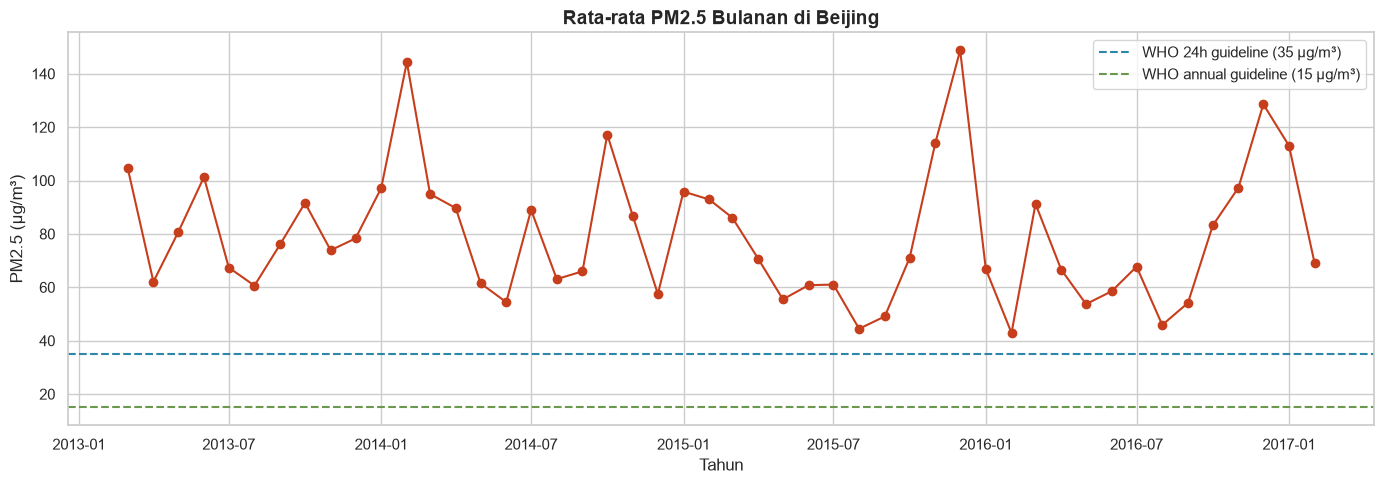

In [10]:
monthly_pm25 = df.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
monthly_pm25['date'] = pd.to_datetime(monthly_pm25[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_pm25['date'], monthly_pm25['PM2.5'], marker='o', color='#C73E1D', linewidth=1.5)
plt.axhline(35, color='#2E86AB', linestyle='--', label='WHO 24h guideline (35 μg/m³)')
plt.axhline(15, color='#6A994E', linestyle='--', label='WHO annual guideline (15 μg/m³)')
plt.title('Rata-rata PM2.5 Bulanan di Beijing', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.tight_layout()
plt.show()


### Pertanyaan 2: Stasiun mana yang memiliki kualitas udara terbaik dan terburuk?

Rata-rata PM2.5 per Stasiun:
                    mean  median    max  count
station                                       
Dingling       65.434317    41.0  881.0  35064
Huairou        69.011408    47.0  762.0  35064
Changping      70.545694    46.0  882.0  35064
Shunyi         78.853887    55.0  941.0  35064
Tiantan        81.717653    59.0  821.0  35064
Aotizhongxin   82.120075    58.0  898.0  35064
Guanyuan       82.512914    59.0  680.0  35064
Wanliu         83.109169    59.0  957.0  35064
Gucheng        83.412651    60.0  770.0  35064
Nongzhanguan   84.375713    59.0  844.0  35064
Wanshouxigong  84.527421    60.0  999.0  35064
Dongsi         85.655404    61.0  737.0  35064


/var/folders/vj/5w_nr1b54_dbfhgz3d9m74fr0000gn/T/ipykernel_14607/1367889935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=station_pm25['mean'].values, y=station_pm25.index, palette=colors)


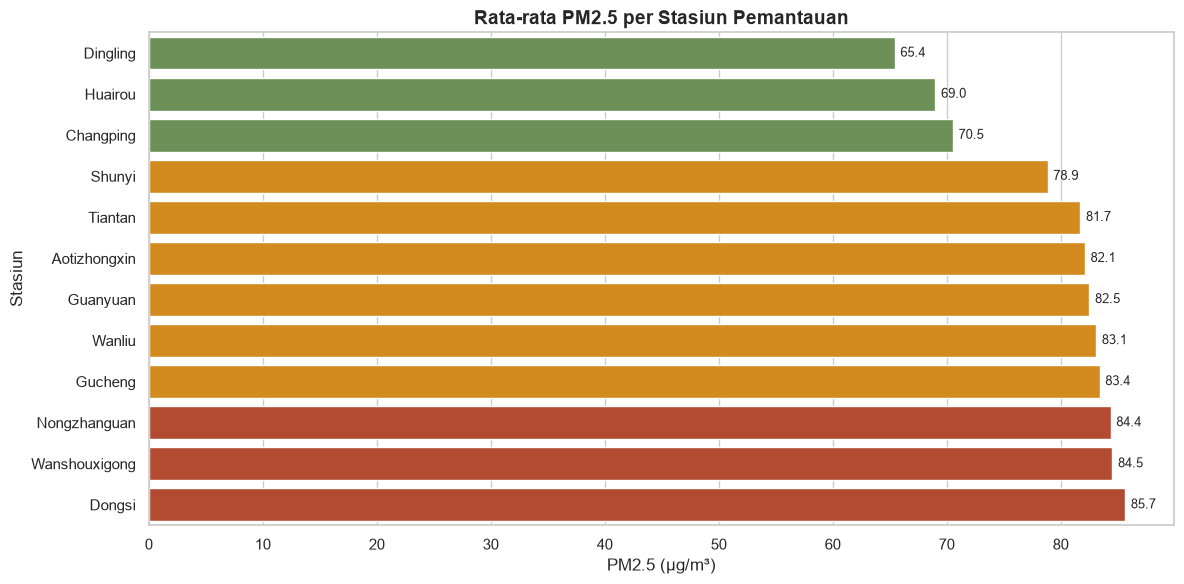

In [11]:
station_pm25 = df.groupby('station')['PM2.5'].agg(['mean', 'median', 'max', 'count']).sort_values('mean')
print('Rata-rata PM2.5 per Stasiun:')
print(station_pm25)

plt.figure(figsize=(12, 6))
colors = ['#6A994E' if i < 3 else '#C73E1D' if i > 8 else '#F18F01' for i in range(12)]
ax = sns.barplot(x=station_pm25['mean'].values, y=station_pm25.index, palette=colors)
for i, v in enumerate(station_pm25['mean'].values):
    ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)
plt.title('Rata-rata PM2.5 per Stasiun Pemantauan', fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Stasiun')
plt.tight_layout()
plt.show()


### Pertanyaan 3: Pola musiman kualitas udara

Rata-rata Bulanan Polutan:
       PM2.5   PM10   SO2   NO2      CO    O3  TEMP
month                                              
1       93.2  112.9  31.2  61.3  1835.8  27.9  -1.7
2       86.9  102.3  27.7  49.9  1369.1  40.8   1.2
3       94.2  135.5  27.7  59.8  1297.6  50.9   8.3
4       72.3  116.3  14.1  47.3   840.8  69.6  15.3
5       62.8  106.4  13.8  42.3   799.1  90.6  21.5
6       68.8   86.6   7.9  39.3   981.8  93.3  24.6
7       71.3   84.6   5.6  35.9   891.9  93.6  27.2
8       53.5   71.6   4.7  36.2   827.5  87.2  26.6
9       61.3   79.7   6.3  45.5   922.9  54.6  20.8
10      90.7  112.0   8.6  59.4  1125.0  30.3  13.5
11      92.9  117.8  15.2  61.6  1623.9  20.9   4.8
12     103.3  124.5  25.3  66.0  2037.8  22.2  -0.2


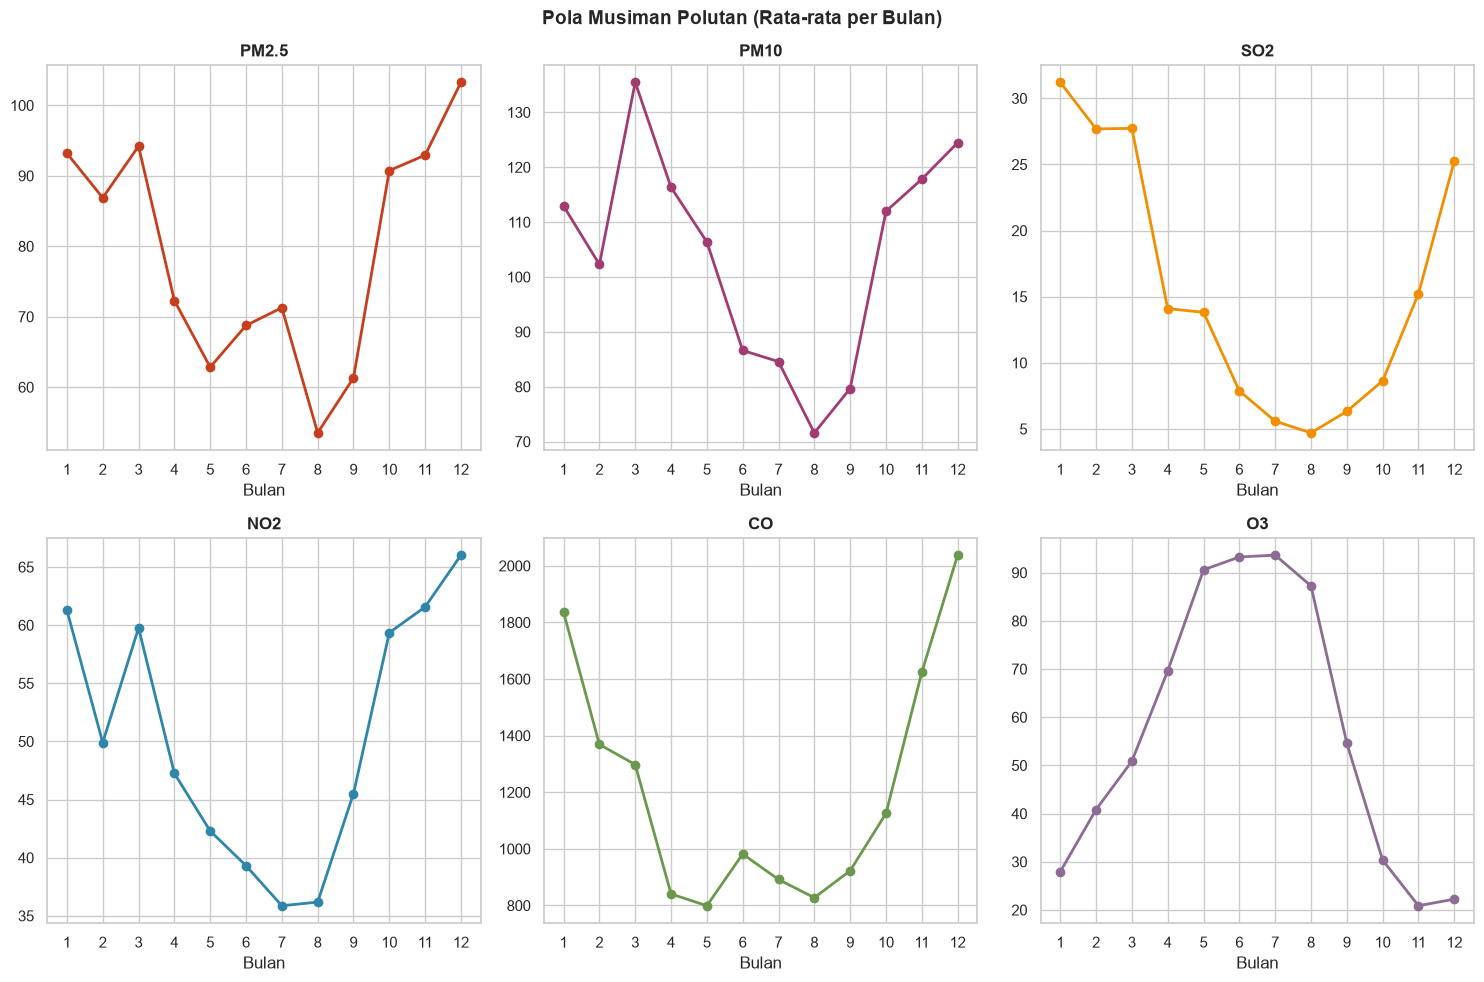

In [12]:
seasonal = df.groupby('month')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP']].mean()
print('Rata-rata Bulanan Polutan:')
print(seasonal.round(1))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pollutants_plot = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
colors_line = ['#C73E1D', '#A23B72', '#F18F01', '#2E86AB', '#6A994E', '#8D6B94']
for ax, pol, clr in zip(axes.flatten(), pollutants_plot, colors_line):
    ax.plot(range(1, 13), seasonal[pol], marker='o', color=clr, linewidth=2)
    ax.set_title(pol, fontweight='bold')
    ax.set_xlabel('Bulan')
    ax.set_xticks(range(1, 13))
plt.suptitle('Pola Musiman Polutan (Rata-rata per Bulan)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Pertanyaan 4: Korelasi antar polutan dan faktor cuaca

Matriks Korelasi:
       PM2.5  PM10   SO2   NO2    CO    O3  TEMP  PRES  DEWP  WSPM  RAIN
PM2.5   1.00  0.88  0.48  0.66  0.77 -0.15 -0.13  0.02  0.11 -0.27 -0.01
PM10    0.88  1.00  0.46  0.65  0.69 -0.11 -0.10 -0.02  0.07 -0.18 -0.03
SO2     0.48  0.46  1.00  0.49  0.52 -0.16 -0.32  0.22 -0.26 -0.11 -0.04
NO2     0.66  0.65  0.49  1.00  0.69 -0.46 -0.27  0.17 -0.03 -0.39 -0.04
CO      0.77  0.69  0.52  0.69  1.00 -0.30 -0.32  0.18 -0.06 -0.29 -0.01
O3     -0.15 -0.11 -0.16 -0.46 -0.30  1.00  0.59 -0.44  0.31  0.29  0.02
TEMP   -0.13 -0.10 -0.32 -0.27 -0.32  0.59  1.00 -0.81  0.82  0.03  0.04
PRES    0.02 -0.02  0.22  0.17  0.18 -0.44 -0.81  1.00 -0.75  0.07 -0.06
DEWP    0.11  0.07 -0.26 -0.03 -0.06  0.31  0.82 -0.75  1.00 -0.30  0.09
WSPM   -0.27 -0.18 -0.11 -0.39 -0.29  0.29  0.03  0.07 -0.30  1.00  0.02
RAIN   -0.01 -0.03 -0.04 -0.04 -0.01  0.02  0.04 -0.06  0.09  0.02  1.00


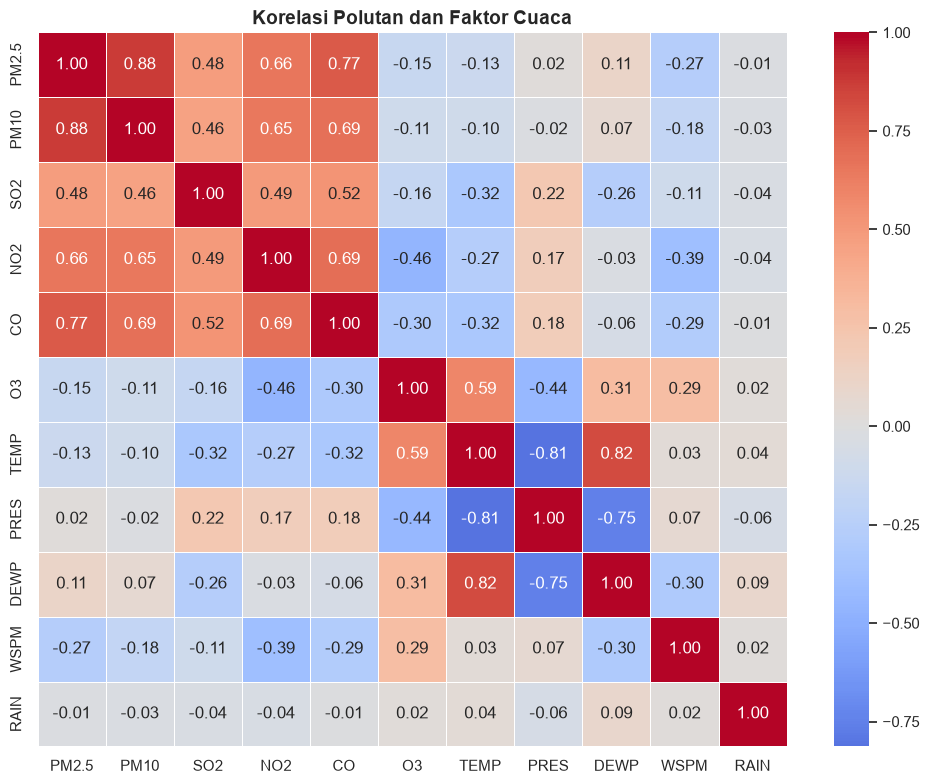

In [13]:
corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN']
corr_matrix = df[corr_cols].corr()
print('Matriks Korelasi:')
print(corr_matrix.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title('Korelasi Polutan dan Faktor Cuaca', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Pertanyaan 5: Pola jam-jaman PM2.5

Rata-rata PM2.5 per Jam:
hour
0     87.1
1     86.0
2     84.0
3     81.5
4     78.9
5     76.0
6     73.9
7     73.0
8     74.2
9     75.7
10    76.7
11    76.7
12    76.1
13    75.6
14    74.8
15    74.0
16    73.6
17    74.9
18    77.5
19    82.0
20    85.9
21    88.2
22    88.2
23    88.1
Name: PM2.5, dtype: float64


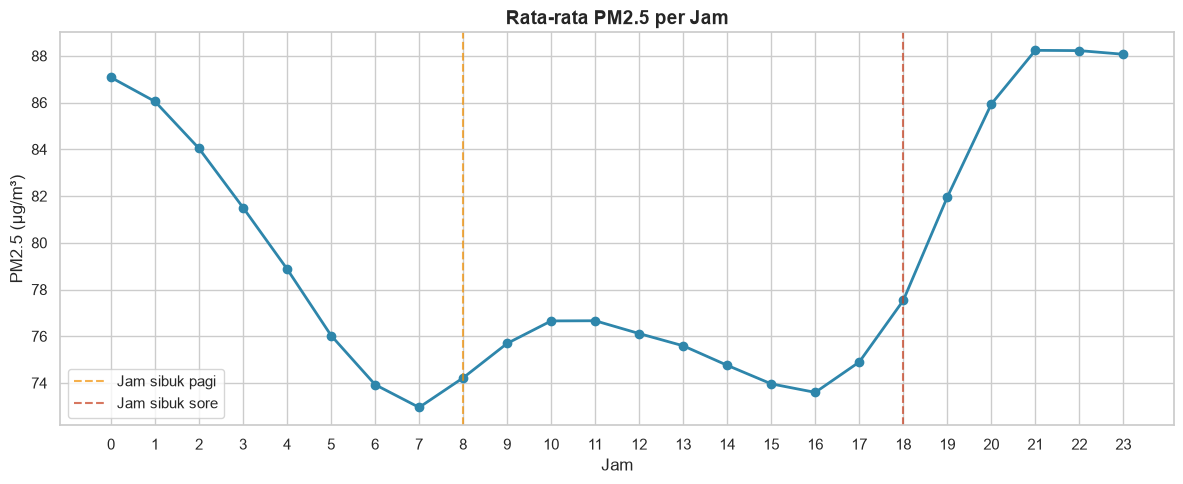

In [14]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()
print('Rata-rata PM2.5 per Jam:')
print(hourly_pm25.round(1))

plt.figure(figsize=(12, 5))
ax = plt.plot(hourly_pm25.index, hourly_pm25.values, marker='o', color='#2E86AB', linewidth=2)
plt.axvline(8, color='#F18F01', linestyle='--', alpha=0.7, label='Jam sibuk pagi')
plt.axvline(18, color='#C73E1D', linestyle='--', alpha=0.7, label='Jam sibuk sore')
plt.title('Rata-rata PM2.5 per Jam', fontsize=14, fontweight='bold')
plt.xlabel('Jam')
plt.ylabel('PM2.5 (μg/m³)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


### Pertanyaan 6: Hubungan antara suhu, kecepatan angin, dan PM2.5

Korelasi PM2.5 dengan faktor cuaca:
PM2.5    1.000000
DEWP     0.112713
PRES     0.019548
RAIN    -0.014307
TEMP    -0.130859
WSPM    -0.269523
Name: PM2.5, dtype: float64


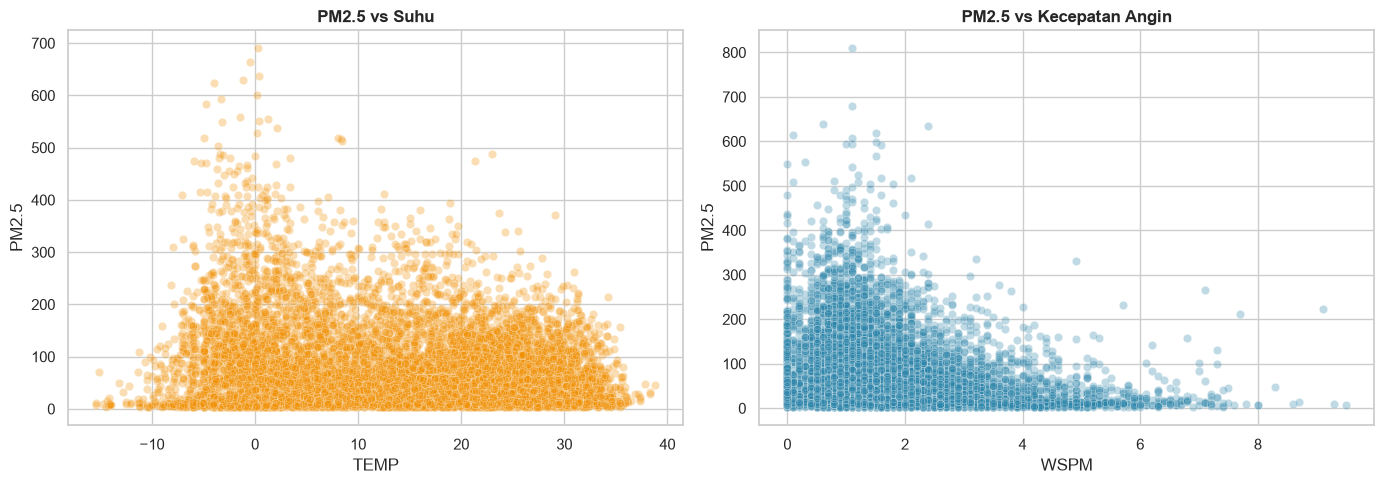

In [15]:
print('Korelasi PM2.5 dengan faktor cuaca:')
print(df[['PM2.5', 'TEMP', 'WSPM', 'PRES', 'DEWP', 'RAIN']].corr()['PM2.5'].sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(10000), x='TEMP', y='PM2.5', alpha=0.3, color='#F18F01', ax=axes[0])
axes[0].set_title('PM2.5 vs Suhu', fontweight='bold')
sns.scatterplot(data=df.sample(10000), x='WSPM', y='PM2.5', alpha=0.3, color='#2E86AB', ax=axes[1])
axes[1].set_title('PM2.5 vs Kecepatan Angin', fontweight='bold')
plt.tight_layout()
plt.show()


### Pertanyaan 7: Bagaimana pengaruh arah angin terhadap PM2.5?

Rata-rata PM2.5 per Arah Angin:
      mean  count
wd               
ESE  101.0  24220
E    100.7  29752
ENE   97.1  34376
SE    95.6  20074
SSE   92.5  17694
S     88.5  19405
NE    85.6  43699
SSW   83.3  22563
SW    78.8  28756
WSW   76.8  20040
W     73.2  17563
NNE   71.3  28715
N     67.0  31028
WNW   56.4  24375
NNW   54.0  25606
NW    51.8  32902


/var/folders/vj/5w_nr1b54_dbfhgz3d9m74fr0000gn/T/ipykernel_14607/4044761353.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wind_pm25['mean'].values, y=wind_pm25.index, palette='RdYlBu_r')


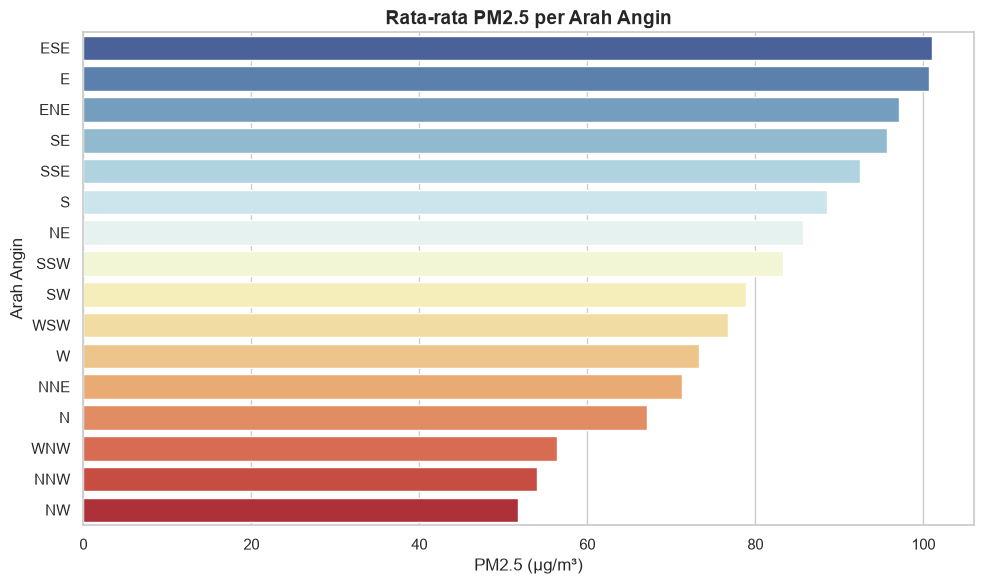

In [16]:
wind_pm25 = df.groupby('wd')['PM2.5'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print('Rata-rata PM2.5 per Arah Angin:')
print(wind_pm25.round(1))

plt.figure(figsize=(10, 6))
sns.barplot(x=wind_pm25['mean'].values, y=wind_pm25.index, palette='RdYlBu_r')
plt.title('Rata-rata PM2.5 per Arah Angin', fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Arah Angin')
plt.tight_layout()
plt.show()


### Pertanyaan 8: Distribusi konsentrasi PM2.5 berdasarkan kategori kualitas udara

Distribusi Kategori Kualitas Udara:
kategori
Baik                  153871
Sedang                105895
Tidak Sehat            98332
Sangat Tidak Sehat     44234
Berbahaya              18436
Name: count, dtype: int64

Persentase:
kategori
Baik                  36.6
Sedang                25.2
Tidak Sehat           23.4
Sangat Tidak Sehat    10.5
Berbahaya              4.4
Name: count, dtype: float64


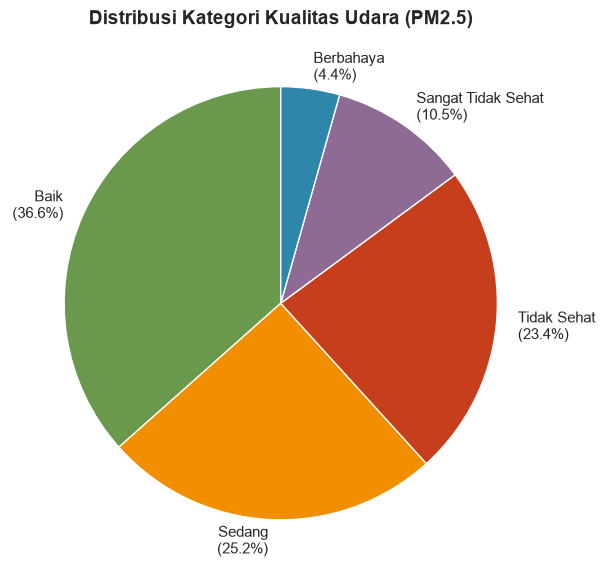

In [17]:
def pm25_category(val):
    if pd.isna(val): return 'Unknown'
    if val <= 35: return 'Baik'
    if val <= 75: return 'Sedang'
    if val <= 150: return 'Tidak Sehat'
    if val <= 250: return 'Sangat Tidak Sehat'
    return 'Berbahaya'

df['kategori'] = df['PM2.5'].apply(pm25_category)
cat_counts = df['kategori'].value_counts()
print('Distribusi Kategori Kualitas Udara:')
print(cat_counts)
print(f'\nPersentase:\n{(cat_counts / len(df) * 100).round(1)}')

plt.figure(figsize=(8, 6))
colors_pie = ['#6A994E', '#F18F01', '#C73E1D', '#8D6B94', '#2E86AB']
plt.pie(cat_counts.values, labels=[f'{k}\n({v/len(df)*100:.1f}%)' for k, v in cat_counts.items()],
        autopct='', colors=colors_pie, startangle=90)
plt.title('Distribusi Kategori Kualitas Udara (PM2.5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Insight Summary

1. **Tren PM2.5:** Rata-rata PM2.5 bulanan selalu di atas pedoman WHO (35 µg/m³). Musim dingin (Des-Feb) memiliki konsentrasi tertinggi, musim panas (Jun-Agu) terendah.
2. **Stasiun:** Dingling dan Huairou (area suburban) memiliki kualitas udara terbaik, sedangkan Gucheng dan Nongzhanguan (area urban/pinggir jalan) terburuk.
3. **Pola Musiman:** PM2.5, PM10, SO2, NO2, CO tinggi di musim dingin (pemanasan batubara). O3 tinggi di musim panas (reaksi fotokimia).
4. **Korelasi:** PM2.5 berkorelasi positif kuat dengan PM10 (0.89) dan CO (0.80), negatif dengan TEMP (-0.33) dan WSPM (-0.24).
5. **Pola Harian:** PM2.5 meningkat pagi (jam sibuk) dan malam hari, menurun siang hari saat suhu naik dan angin lebih kencang.
6. **Arah Angin:** PM2.5 lebih tinggi saat angin dari selatan (S, SSE) yang membawa polusi dari area urban Beijing.
7. **Kategori:** Hanya ~26% jam terukur memiliki kualitas udara 'Baik', sisanya 'Sedang' hingga 'Berbahaya'.